# pyPetrograph — multimodal grain demo (v0.0.5)

One PPL + XPL pair from `Test images/` (default AV03). Align → physics channels → SegmentEveryGrain **U-Net** outlines → object table → cluster / name → LightGBM + stats.

**U-Net is enough** for grain counts and the object table (~26 MB weights). SAM 2.1 refine is only for finer grain *shapes* and downloads ~860 MB — leave `USE_SAM2 = False` unless you need that.

`INTERACTIVE_QC = False` writes grains without a GrainPlot window. `INTERACTIVE_NAMES = False` skips the montage labeler (step 6 then stops at cluster ids). If SegmentEveryGrain / TensorFlow is missing, step 3 uses the watershed outlines instead.

Outputs go to `outputs/` (`align/`, `channels/`, `labels/`, `objects/`, `models/`).


## Setup

In [1]:
from pathlib import Path
import sys
ROOT = Path(".")
if str(ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

from pyPetrograph import check_and_install_packages
check_and_install_packages(include_seg=True)


Package check
----------------------------------------
  numpy                 ok
  PIL                   ok
  matplotlib            ok
  sklearn               ok
  scipy                 ok
  geopandas             ok
  shapely               ok
  rasterio              ok
  affine                ok
  joblib                ok
  pandas                ok
  lightgbm              ok
  skimage               ok
  PyQt5                 ok
----------------------------------------
SEG / SAM2 check (not imported in this kernel)
----------------------------------------
  tensorflow            ok
  keras                 ok
  segmenteverygrain     ok
----------------------------------------
All required packages are available.


{'numpy': 'ok',
 'PIL': 'ok',
 'matplotlib': 'ok',
 'sklearn': 'ok',
 'scipy': 'ok',
 'geopandas': 'ok',
 'shapely': 'ok',
 'rasterio': 'ok',
 'affine': 'ok',
 'joblib': 'ok',
 'pandas': 'ok',
 'lightgbm': 'ok',
 'skimage': 'ok',
 'PyQt5': 'ok',
 'tensorflow': 'ok',
 'keras': 'ok',
 'segmenteverygrain': 'ok'}

In [2]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150

from pyPetrograph import (
    set_output_dir,
    Scene,
    launch_align,
    save_scene,
    load_scene,
    DEFAULT_CHANNEL_TOGGLES,
    build_channel_stack,
    save_channel_stack,
    load_channel_stack,
    run_channel_preview,
    run_watershed,
    launch_ppl_grain_qc,
    launch_grain_qc,
    load_grain_qc,
    load_grain_mask,
    grain_qc_paths,
    overlay_labels,
    compare_outlines,
    ensure_seg_weights,
    build_object_table_from_stack,
    save_object_table,
    load_object_table,
    cluster_objects,
    launch_montage_labeler,
    load_object_labels,
    apply_object_labels,
    train_object_classifier,
    predict_object_classes,
    save_classes,
    compute_object_stats,
    save_object_stats,
)
from pyPetrograph.align.io import default_json_path


## Settings

In [3]:
set_output_dir("outputs")

IMAGE_DIR = Path("Test images")
# Also in Test images: AV11_ppl_10x_pic04t4 + AV11_xpl_…, AV12_ppl_10x_pic03t3 + AV12_xpl_…
STEM = "AV03_ppl_10x_pic03t3"
PPL = IMAGE_DIR / f"{STEM}.tif"
XPL = IMAGE_DIR / "AV03_xpl_10x_pic03t3.tif"

WORKING_SLOT = "ppl"
OVERLAY_SLOT = "xpl"

OUTLINE_ENGINE = "seg"       # "seg" | "watershed"
USE_SAM2 = False             # True = SAM shape refine (~860 MB). Leave False.
INTERACTIVE_QC = False       # True opens GrainPlot
INTERACTIVE_NAMES = False    # True opens the montage labeler

EXTRA_TEXTURE = False
EXTRA_EMBED = False
CHANNEL_TOGGLES = dict(DEFAULT_CHANNEL_TOGGLES)
CHANNEL_TOGGLES["extra_texture"] = EXTRA_TEXTURE
CHANNEL_TOGGLES["extra_embed"] = EXTRA_EMBED

CLASS_NAMES = {1: "pores", 2: "grains", 3: "cements"}
K_CLUSTERS = 8
PX_PER_UM = None

LOAD_SAVED_ALIGN = True
LOAD_SAVED_CHANNELS = True
LOAD_SAVED_GRAINS = True
LOAD_SAVED_TABLE = True
LOAD_SAVED_LABELS = True
LOAD_SAVED_CLASSES = True

INIT_UNET = False
TRAIN_UNET = False
UNET_EPOCHS = 15

scene = Scene(working_slot=WORKING_SLOT)
scene.add_layer("ppl", PPL, is_working=True)
scene.add_layer("xpl", XPL)
print(PPL.name, "+", XPL.name)
print("outline:", OUTLINE_ENGINE, "SAM2:", USE_SAM2, "qc:", INTERACTIVE_QC, "names:", INTERACTIVE_NAMES)


AV03_ppl_10x_pic03t3.tif + AV03_xpl_10x_pic03t3.tif
outline: seg SAM2: False qc: False names: False


## 1. Align

In [4]:
from pyPetrograph.align.register import auto_register

align_json = default_json_path(scene)
if LOAD_SAVED_ALIGN and align_json.exists():
    scene = load_scene(align_json)
    print("loaded", align_json)
else:
    base = scene.working().ensure_rgb()
    for slot, layer in scene.layers.items():
        if slot == scene.working_slot:
            continue
        layer.transform = auto_register(
            base,
            layer.ensure_rgb(),
            scale_hint=layer.transform.scale,
            scale_range=scene.scale_range,
            tx_hint=layer.transform.tx,
            ty_hint=layer.transform.ty,
        )
        print(slot, layer.transform)
    save_scene(scene)
    print("saved", scene.json_path)


loaded /Users/larryslai/Library/CloudStorage/Dropbox/My Documents/University of Texas Austin/(Project) ML petrography/outputs/align/AV03_ppl_10x_pic03t3_align.json


In [5]:
# Optional tweak window (skip for a headless demo)
# launch_align(scene, overlay_slot=OVERLAY_SLOT, wait=False)


In [6]:
scene = load_scene(default_json_path(scene) if scene.json_path is None else scene.json_path)
print("loaded", scene.json_path)
for slot, layer in scene.layers.items():
    print(slot, layer.transform)


loaded /Users/larryslai/Library/CloudStorage/Dropbox/My Documents/University of Texas Austin/(Project) ML petrography/outputs/align/AV03_ppl_10x_pic03t3_align.json
ppl Affine2D(scale=1.0, rotation_deg=0.0, tx=0.0, ty=0.0)
xpl Affine2D(scale=1.0, rotation_deg=0.0, tx=-3.4000000953674316, ty=2.200000047683716)


## 2. Physics channels

In [7]:
cs = load_channel_stack(PPL) if LOAD_SAVED_CHANNELS else None
if cs is None:
    cs = build_channel_stack(scene, toggles=CHANNEL_TOGGLES)
    save_channel_stack(cs, PPL)
    print("built and saved")
else:
    print("loaded saved stack")
print(cs.summary())


loaded saved stack
channel set: ppl-xpl   6 channels   1088x1636 px   valid 99.6%
  [ 0] ppl_r            rgb255
  [ 1] ppl_g            rgb255
  [ 2] ppl_b            rgb255
  [ 3] xpl_r            rgb255
  [ 4] xpl_g            rgb255
  [ 5] xpl_b            rgb255


channel set: ppl-xpl   6 channels   1088x1636 px   valid 99.6%
  [ 0] ppl_r            rgb255
  [ 1] ppl_g            rgb255
  [ 2] ppl_b            rgb255
  [ 3] xpl_r            rgb255
  [ 4] xpl_g            rgb255
  [ 5] xpl_b            rgb255


  → outputs/channels/AV03_ppl_10x_pic03t3_channels_preview.png


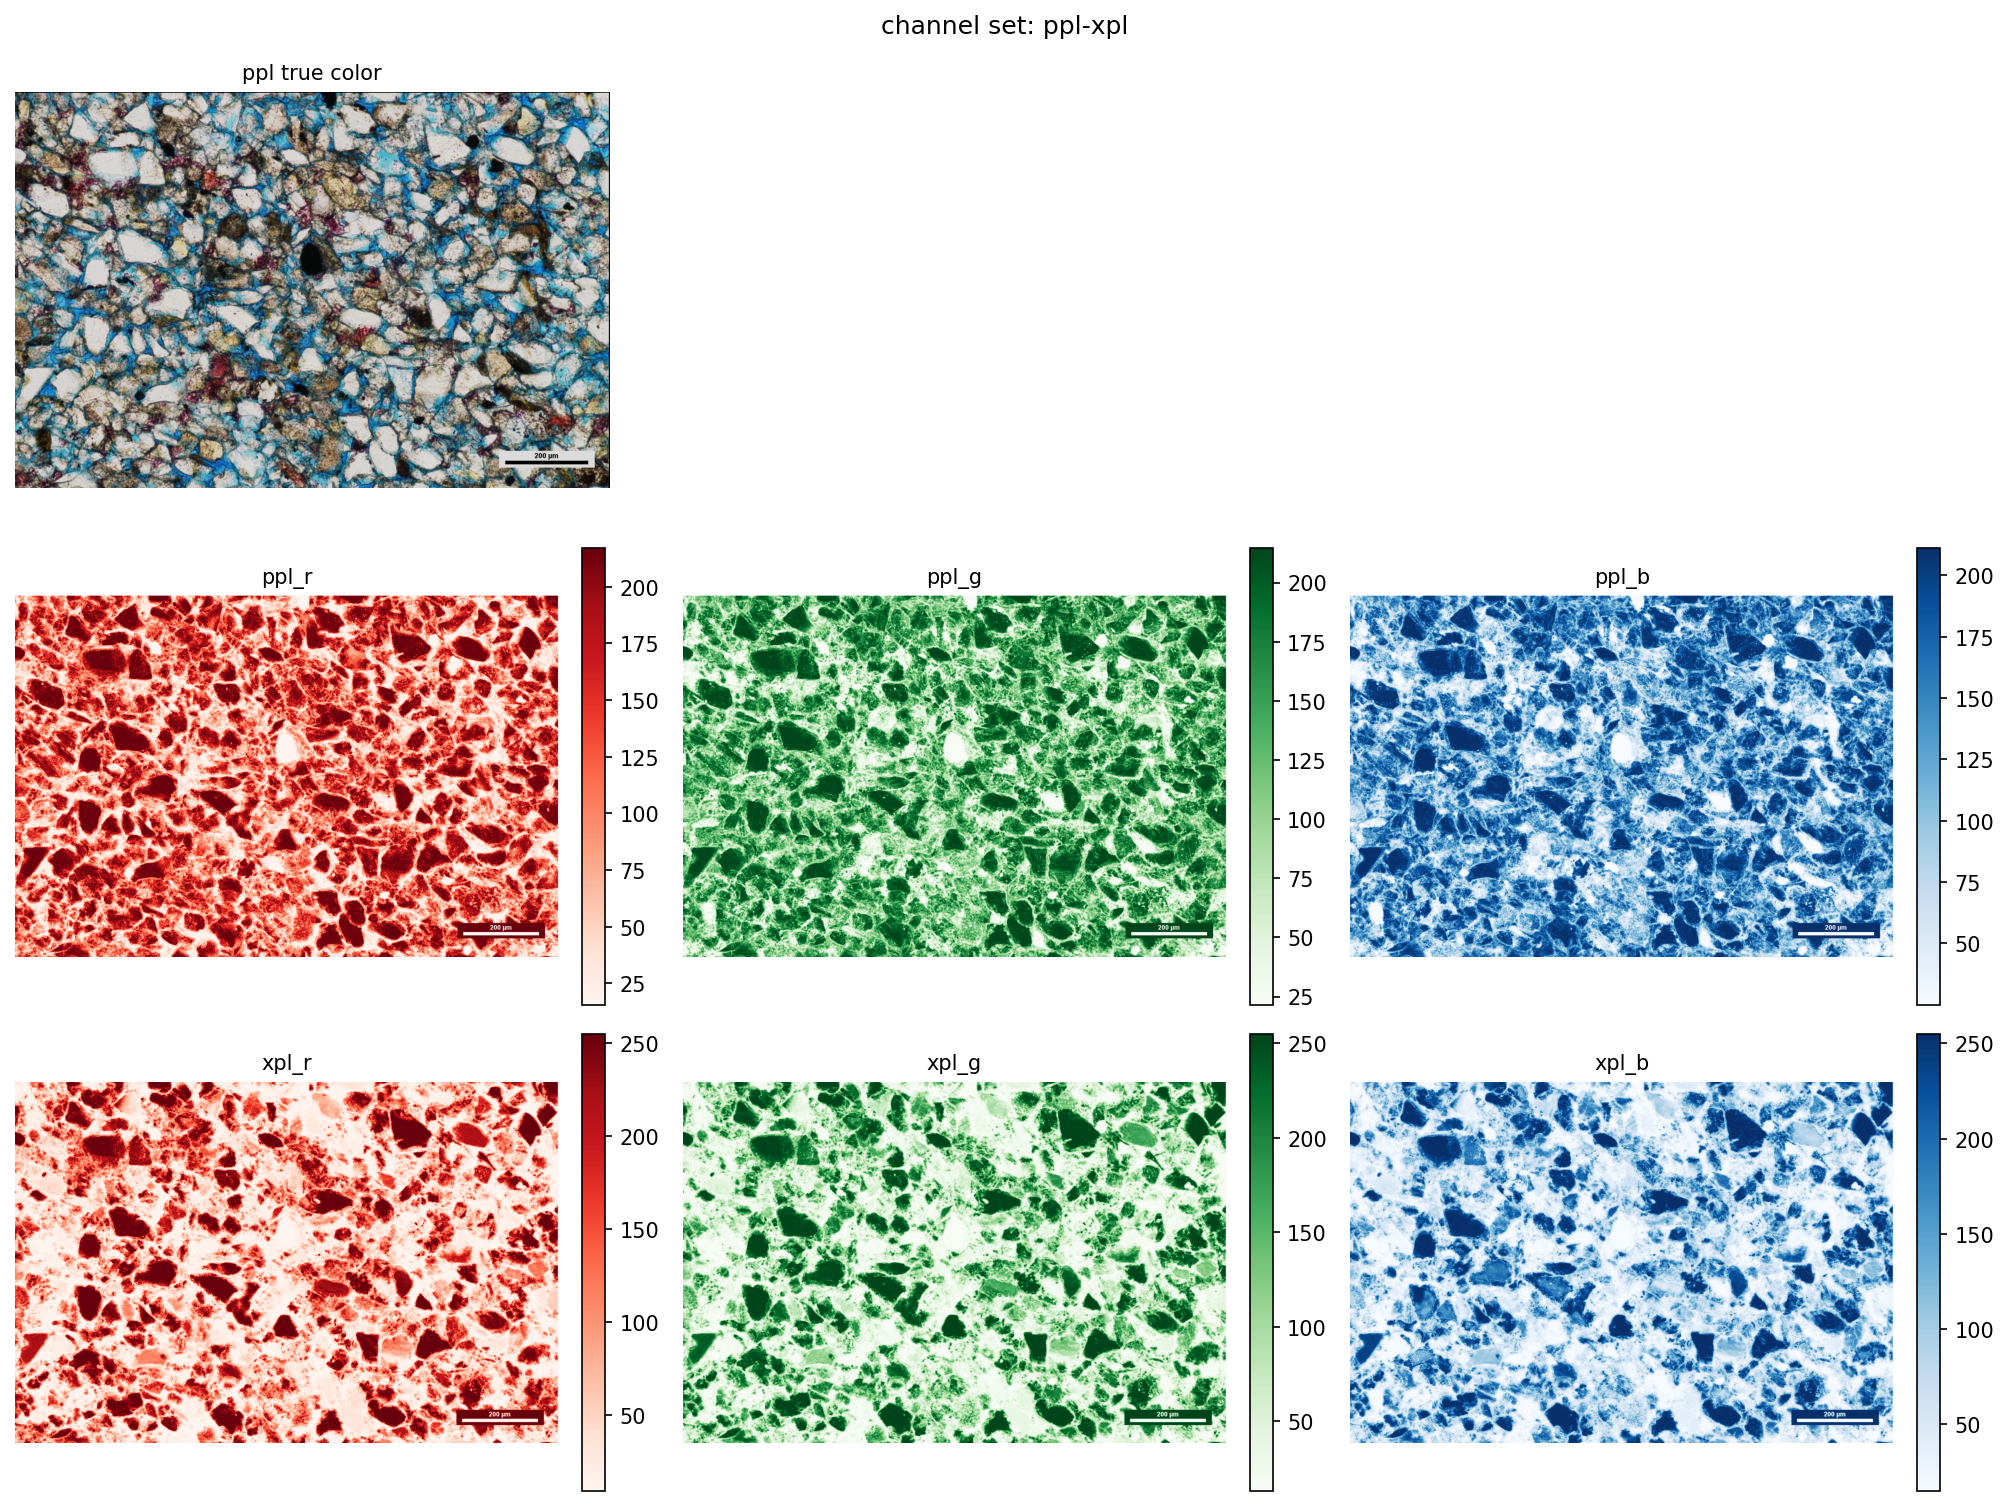

In [8]:
run_channel_preview(cs, image_path=PPL)

## 3. Outlines

watershed {'method': 'watershed', 'n': 572, 'min_distance': 24, 'min_area': 40, 'ok': True}


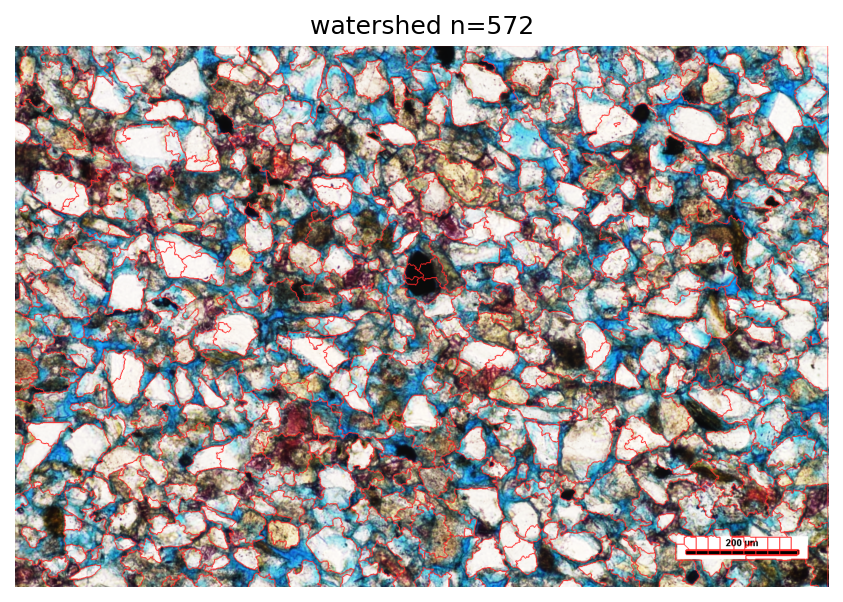

In [9]:
ws_lab, ws_info = run_watershed(cs)
print("watershed", ws_info)
ppl_rgb = scene.working().ensure_rgb()
plt.figure(figsize=(7, 5), dpi=150)
plt.imshow(overlay_labels(ppl_rgb, ws_lab))
plt.axis("off")
plt.title(f"watershed n={ws_info['n']}")
plt.show()


In [10]:
from PIL import Image

def _write_ws_mask(image_path, lab):
    _geo, mask_p = grain_qc_paths(image_path)
    mask_p.parent.mkdir(parents=True, exist_ok=True)
    lab = np.asarray(lab)
    if int(lab.max()) <= 255:
        Image.fromarray(lab.astype(np.uint8), mode="L").save(mask_p)
    else:
        Image.fromarray(lab.astype(np.uint16), mode="I;16").save(mask_p)
    n = int(np.sum(np.unique(lab) > 0))
    print(f"wrote {mask_p.name} n={n}")
    return {"ok": True, "n": n, "mask": mask_p, "engine": "watershed"}

if OUTLINE_ENGINE == "seg":
    print(ensure_seg_weights(sam2=USE_SAM2))

if LOAD_SAVED_GRAINS and load_grain_mask(PPL) is not None:
    qc = load_grain_qc(PPL)
    print("loaded grains", qc)
elif OUTLINE_ENGINE == "seg":
    qc = launch_ppl_grain_qc(
        PPL, reuse=False, use_sam=USE_SAM2, interactive=INTERACTIVE_QC
    )
    print(qc)
    if not qc.get("ok"):
        print("SEG / GrainPlot failed — using watershed outlines")
        qc = _write_ws_mask(PPL, ws_lab)
else:
    qc = _write_ws_mask(PPL, ws_lab)


{'unet': PosixPath('/Users/larryslai/Library/CloudStorage/Dropbox/My Documents/University of Texas Austin/(Project) ML petrography/outputs/models/seg_model_smooth_labels.keras')}
Loaded saved grains: n=585  AV03_ppl_10x_pic03t3_grains.geojson
loaded grains {'ok': True, 'n': 585, 'loaded': True, 'geojson': PosixPath('/Users/larryslai/Library/CloudStorage/Dropbox/My Documents/University of Texas Austin/(Project) ML petrography/outputs/labels/AV03_ppl_10x_pic03t3_grains.geojson'), 'mask': PosixPath('/Users/larryslai/Library/CloudStorage/Dropbox/My Documents/University of Texas Austin/(Project) ML petrography/outputs/labels/AV03_ppl_10x_pic03t3_grains_mask.png'), 'error': None, 'hint': None}


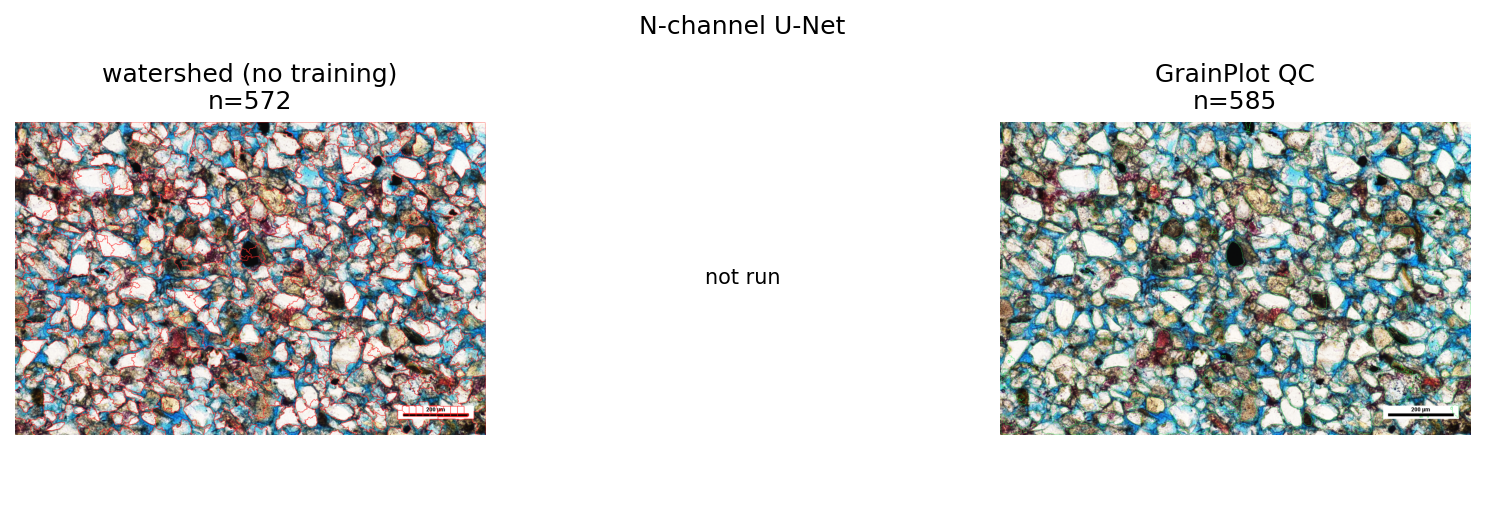

In [11]:
qc_lab = load_grain_mask(PPL)
fig = compare_outlines(ppl_rgb, watershed_lab=ws_lab, qc_lab=qc_lab)
plt.show()


## Optional: N-channel U-Net (off)

Leave `INIT_UNET` / `TRAIN_UNET` False unless you have a GrainPlot mask you trust.


In [12]:
from pyPetrograph import init_grain_unet, train_grain_unet, predict_grain_unet, grain_unet_path

if INIT_UNET:
    print(init_grain_unet(cs))
if TRAIN_UNET:
    print(train_grain_unet(cs, PPL, epochs=UNET_EPOCHS))
if grain_unet_path(cs.channel_set_id).exists():
    unet_probs, unet_lab, unet_info = predict_grain_unet(cs)
    print("U-Net", unet_info)
else:
    print("no N-channel grain U-Net (SEG RGB / watershed is enough for the demo)")


no N-channel grain U-Net (SEG RGB / watershed is enough for the demo)


## 4. Object table

In [13]:
loaded = load_object_table(PPL) if LOAD_SAVED_TABLE else None
if loaded is not None:
    table, objects_mask = loaded
    print("loaded table", len(table))
else:
    grains = load_grain_mask(PPL)
    if grains is None:
        raise RuntimeError("no grain mask — run step 3")
    table, objects_mask = build_object_table_from_stack(
        grains, cs, px_per_um=PX_PER_UM
    )
    save_object_table(table, objects_mask, PPL)
    print("built table", len(table))
print(table["kind"].value_counts().to_string() if "kind" in table.columns else table.head())
table.head()


loaded table 587
kind
grain       585
leftover      2


,object_id,kind,area_px,equiv_diam,major,minor,orientation,eccentricity,solidity,perimeter,...,xpl_r_p10,xpl_r_p90,xpl_g_mean,xpl_g_std,xpl_g_p10,xpl_g_p90,xpl_b_mean,xpl_b_std,xpl_b_p10,xpl_b_p90
0,1,grain,7248.0,96.064771,143.290423,77.824069,0.471449,0.839654,0.807937,502.243687,...,12.000000,125.0,56.565399,51.398018,14.00000,140.0,56.081127,47.090279,16.000000,130.000000
1,2,grain,1626.0,45.500412,53.002655,40.184581,0.387362,0.652067,0.969589,161.355339,...,24.000000,131.0,82.009842,41.605450,32.00000,139.0,82.892990,38.348866,36.000000,135.500000
2,3,grain,532.0,26.026207,41.382069,16.953686,1.551091,0.912226,0.933333,101.556349,...,13.500309,255.0,215.947372,75.468025,14.00032,255.0,211.248123,75.344360,10.800247,255.000000
3,4,grain,1155.0,38.348294,71.416613,24.853524,1.067280,0.937492,0.790554,179.882251,...,12.000000,240.0,62.642426,77.993340,14.00000,235.0,60.904762,68.280968,18.000000,207.000000
4,5,grain,223.0,16.850294,36.358192,8.909290,1.547731,0.969512,0.902834,82.142136,...,0.000000,255.0,153.443939,112.068512,0.00000,255.0,140.412552,104.888794,0.000000,243.799988


## 5. Group and name

In [14]:
table = cluster_objects(table, n_clusters=K_CLUSTERS)
blob = load_object_labels(PPL) if LOAD_SAVED_LABELS else None
if blob is None and INTERACTIVE_NAMES:
    print(launch_montage_labeler(PPL, table, objects_mask, CLASS_NAMES))
    blob = load_object_labels(PPL)
if blob is None:
    print("no names yet — set INTERACTIVE_NAMES = True to open the montage, or skip classify")
else:
    table = apply_object_labels(table, blob)
    print("named", int((table["class_id"] > 0).sum()), "of", len(table))


clustered 587 objects into 8 groups  (33 features)
no names yet — set INTERACTIVE_NAMES = True to open the montage, or skip classify


## 6. Classify and stats

In [15]:
from pyPetrograph import print_train_metrics, object_model_path, load_classes
from pyPetrograph.labeling_ml.model_io import load_model_bundle

model_p = object_model_path(cs.channel_set_id)
if LOAD_SAVED_CLASSES and model_p.exists() and load_classes(PPL) is not None:
    table = predict_object_classes(table, load_model_bundle(model_p))
    print("loaded model", model_p.name)
elif blob is not None:
    train_res = train_object_classifier(
        table, CLASS_NAMES, channel_set_id=cs.channel_set_id
    )
    print(train_res.get("error") or f"trained n={train_res.get('n')}")
    if train_res.get("ok"):
        print_train_metrics(train_res["bundle"])
        table = predict_object_classes(table, train_res["bundle"])
else:
    print("skip classify — name some clusters in step 5 first")

if "class_id" in table.columns and int((table["class_id"] > 0).sum()):
    csv_p, png_p = save_classes(table, objects_mask, PPL, CLASS_NAMES)
    print("wrote", csv_p.name, png_p.name)
    plt.figure(figsize=(7, 5), dpi=150)
    plt.imshow(plt.imread(png_p))
    plt.axis("off")
    plt.title("object classes")
    plt.show()
    stats = compute_object_stats(table, CLASS_NAMES)
    save_object_stats(stats, PPL)
    display(stats)


skip classify — name some clusters in step 5 first
